# Part C: Comparative analysis
Compare Part A against Part B on:

- **Error binned by yaw magnitude**. WFLW carries a binary large-pose flag rather than an angle, so yaw has to be derived. Derive it from the ground-truth landmarks, not from either estimator's output. Binning on predicted landmarks makes the bin assignment a function of the error being measured, and does so worst at exactly the angles of interest. PnP against a 3D reference model, or a simpler geometric proxy from the ground-truth points, are both acceptable; state the method and the bin edges.

- **Robustness slices**, covering occlusion and illumination at minimum, using the dataset attributes.

- **Error localization**. Landmark error is not uniform across the face. Report which points fail and under which conditions, not only the aggregate NME.

Address three questions on that basis:

1. Where does each method fail, and what is the underlying mechanism rather than the metric?

2. Do the two methods fail on the same images, and on the same points within an image? Quantify both overlaps and state what follows from them.

3. Which would you deploy, under what conditions, and what evidence would revise that judgement?

Include representative failure images for each method, with predicted and ground-truth points overlaid.

## 1. 준비: Part A/B 예측 로드

`output/results/preds.npz`가 없으면 먼저 `src/notebooks/part_b.ipynb`를 실행할 것
(Part A/B 예측을 함께 캐시해 이 노트북이 재사용한다).

In [1]:
import sys, os
sys.path.append(os.path.abspath("../.."))

In [17]:
from src.shared.nme_metrics import nme_batch
from src.application.comparative_analysis_use_case import yaw_curves, perpoint_heat, overlaps, failure_images
from src.settings import EvalConfig

import numpy as np
import cv2
import matplotlib.pyplot as plt

In [13]:
REPO_ROOT = os.path.abspath("../..")
FIG_PATH = REPO_ROOT+"/figs"

eval_config = EvalConfig()


In [ ]:
preds_result = np.load(f"{REPO_ROOT}/output/results/preds.npz", allow_pickle="True")
preds_a, preds_b, gts, boxes, attrs, img_wh, paths = (
                                                        preds_result["predsA"], 
                                                        preds_result["predsB"], 
                                                        preds_result["gts"], 
                                                        preds_result["boxes"], 
                                                        preds_result["attrs"], 
                                                        preds_result["img_wh"], 
                                                        preds_result["paths"],
                                                    )
occ = attrs[:, 4].astype(bool)
# part_b.ipynb가 이미 절대경로로 저장하므로 REPO_ROOT를 다시 붙이지 않는다.
paths = list(paths)
len(paths)

## 2. yaw 크기별 오차 (정답 landmark에서 PnP로 파생, 3종 정규화 비교)

yaw를 예측이 아니라 GT에서 뽑는 이유, bin 경계, 3D 모델의 한계는
`src/shared/yaw_estimation.py` docstring과 `DESIGN.md` §4.1 참조.

[yaw] saved /Users/ych/work/hoonyandu/wflw_landmark_repo/figs/yaw_curve.png  (정규화별 기울기 차이가 E-2 증거)


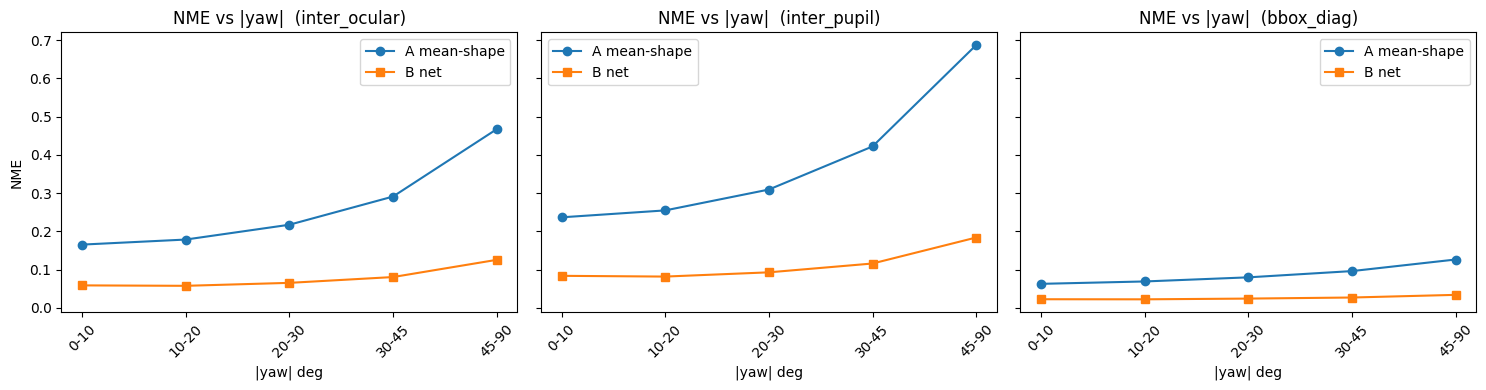

In [ ]:
%matplotlib inline
yaw_bins = [0, 10, 20, 30, 45, 90]
yaws = yaw_curves(gts, img_wh, preds_a, preds_b, boxes, yaw_bins, FIG_PATH)
# 그림은 FIGS/yaw_curve.png에도 저장되고, inline backend가 위 셀 실행 결과로 바로 보여준다.

## 3. 오차 위치화: 점별 NME 히트맵 (occlusion subset, Part B)

[perpoint] saved /Users/ych/work/hoonyandu/wflw_landmark_repo/figs/perpoint_heat.png
occlusion NME 최악 8개 point idx: [32, 0, 31, 1, 30, 29, 2, 28] [0.1386, 0.1365, 0.1332, 0.1297, 0.1285, 0.1248, 0.1241, 0.1215]
가장 안정적인 5개 point idx     : [65, 51, 64, 75, 52] [0.0673, 0.0676, 0.0703, 0.0704, 0.0705]
-> WFLW 98점 스킴에서 0-32는 턱선/윤곽점, 51-75 근처는 코/눈 주변


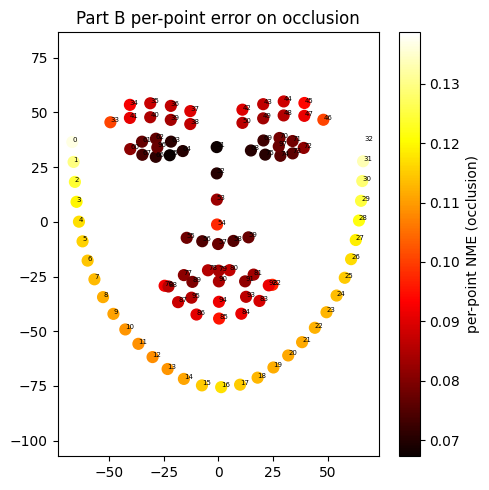

In [10]:
perpoint_heat(gts, preds_b, boxes, occ, FIG_PATH)

# 최악/최선 포인트를 숫자로도 확인 (히트맵 상 색만으로는 인덱스 읽기 어려움)
_, ppall = nme_batch(preds_b, gts, "inter_ocular", boxes)
pp_occ = ppall[occ].mean(0)
worst = np.argsort(pp_occ)[-8:][::-1]
best = np.argsort(pp_occ)[:5]
print("occlusion NME 최악 8개 point idx:", worst.tolist(), [round(float(pp_occ[i]), 4) for i in worst])
print("가장 안정적인 5개 point idx     :", best.tolist(), [round(float(pp_occ[i]), 4) for i in best])
print("-> WFLW 98점 스킴에서 0-32는 턱선/윤곽점, 51-75 근처는 코/눈 주변")

## 4. 겹침(overlap) 정량화: A와 B가 같은 곳에서 실패하는가

이미지 수준 Jaccard가 낮으면 → 오차가 독립적 → Part D의 A–B disagreement
신호가 원리적으로 쓸모 있다는 근거 (단, 완벽하지 않음은 Part D/E-3에서 확인).

In [16]:
img_jaccard = overlaps(gts, preds_a, preds_b, boxes, thr=eval_config.failure_threshold)


[overlap] image-level failure Jaccard = 0.230
[overlap] point-level failure Jaccard (both-fail imgs) = 0.642
  -> 낮을수록 오차가 독립적 -> disagreement 신호 유효(Part D).


## 5. 대표 실패 이미지 (예측·정답 오버레이)

각 방법의 최악 4개 사례를 `figs/failure_{A,B}_*.png`로 저장. 노트북에서도 바로 확인.

[failure] saved worst-4 overlays for A and B -> /Users/ych/work/hoonyandu/wflw_landmark_repo/figs/


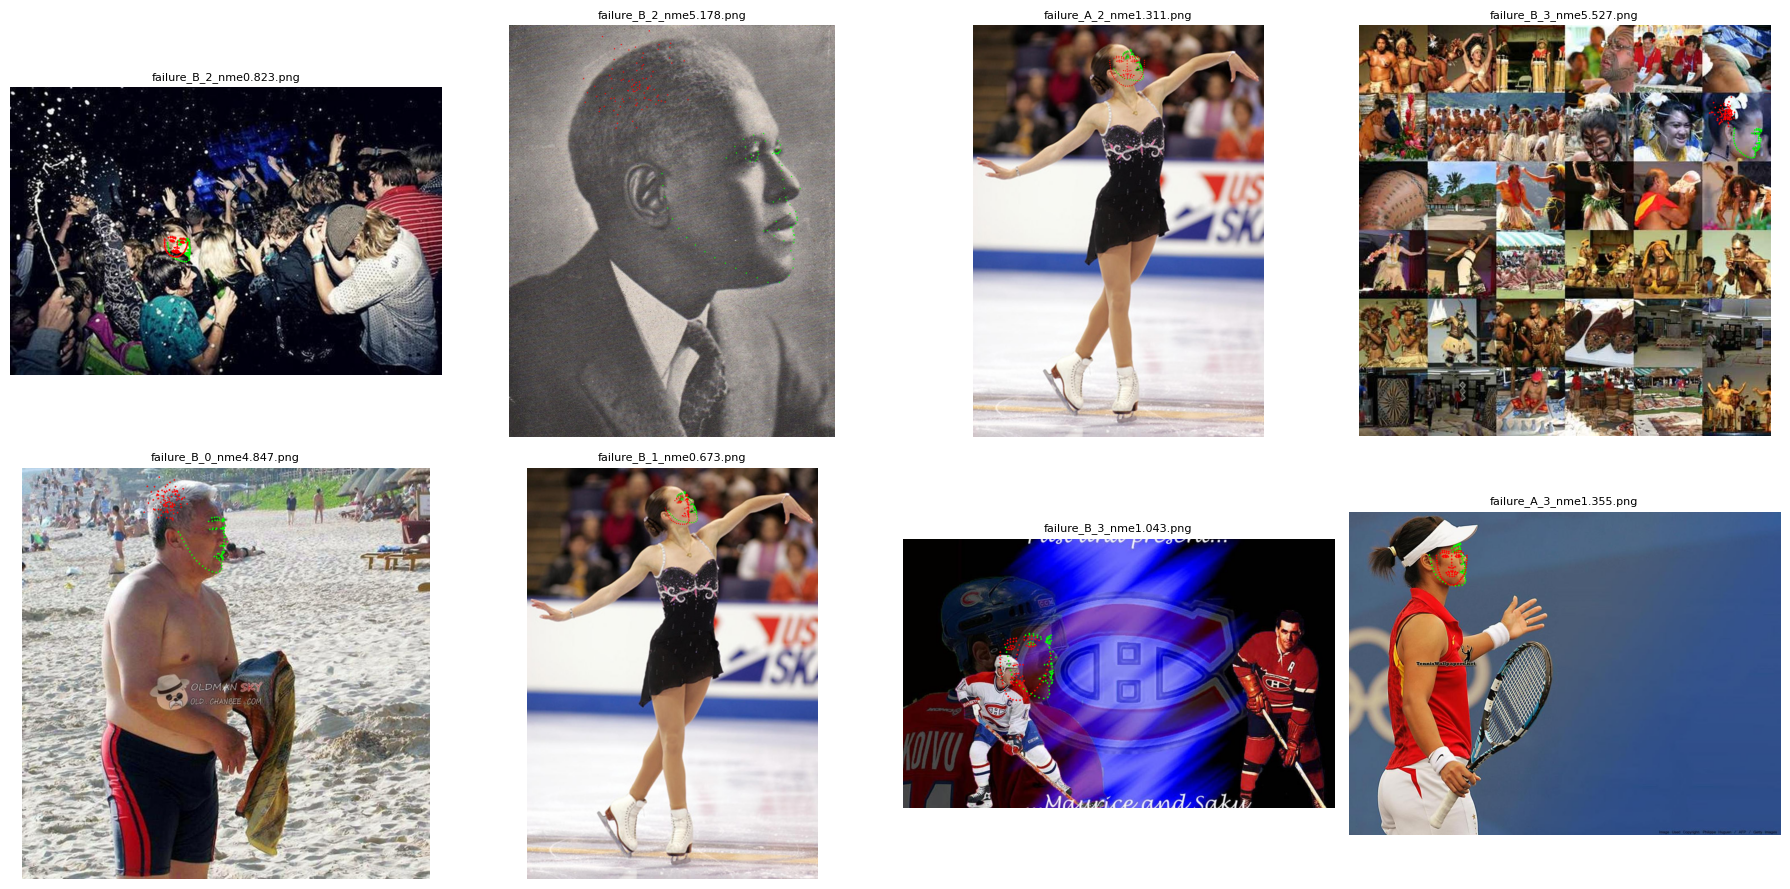

In [ ]:
failure_images(paths, gts, preds_a, preds_b, boxes, FIG_PATH)

# 방금 저장된 파일들을 노트북에도 바로 표시 (worst-4 x A/B)
failure_image_paths = [f"{FIG_PATH}/{path}" for path in os.listdir(FIG_PATH) if "failure" in path]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, p in zip(axes.flat, failure_image_paths):
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(p.split("/")[-1], fontsize=8)
    ax.axis("off")

fig.tight_layout()
plt.show()